In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm
from itertools import product

In [5]:
def comm(A,B):
    return A@B-B@A

In [6]:
a = 1

def TDDM(t,y,mu):
    # y carries all the coupled DE variables in a long vector\
    # rho is 2x2 but flattened into (4,)
    # c2 is 4x4 but flattened into (16,)
    rho = y[:4].reshape(2,2)
    c2 = y[4:].reshape(4,4)
    
    # set up the differentiated variables
    d_rho = np.zeros_like(rho, dtype=complex)
    d_c2 = np.zeros_like(c2, dtype=complex)

    # introduce hamiltonian components
    h0 = a/2*np.array([[1,-1],
                       [-1,1]],dtype=complex)
    v = np.array([[mu,0,0,0],
                  [0,0,0,0],
                  [0,0,0,0],
                  [0,0,0,mu]],dtype=complex)
    # H = np.array([[a+mu,-a/2,-a/2,0],
    #               [-a/2,a,0,-a/2],
    #               [-a/2,0,a,-a/2],
    #               [0,-a/2,-a/2,a+mu]], dtype=complex)
    H = np.kron(h0, np.eye(2,dtype=complex)) + np.kron(np.eye(2,dtype=complex), h0) + v
    
    # first d_rho equation
    d_rho += comm(h0,rho)

    comm4 = comm(v, np.kron(rho,rho)+c2)
    comm4 = comm4.reshape(2,2,2,2)
    tr2 = np.trace(comm4, axis1=1, axis2=3) # to trace over particle 2
    d_rho += tr2

    # divide by i
    d_rho = -1j*d_rho
    assert d_rho.shape == (2,2)
    
    

    # now d_c2 equation
    d_c2 += comm(H, c2)
    d_c2 += comm(v, np.kron(rho,rho))

    # now the trace over 3 term:
    v23 = np.kron(np.eye(2,dtype=complex),v)
    # need permutation matrix to get v13, where v13 = P23 v12 P23
    P23 = np.array([[1, 0, 0, 0, 0, 0, 0, 0],
                    [0, 0, 1, 0, 0, 0, 0, 0],
                    [0, 1, 0, 0, 0, 0, 0, 0],
                    [0, 0, 0, 1, 0, 0, 0, 0],
                    [0, 0, 0, 0, 1, 0, 0, 0],
                    [0, 0, 0, 0, 0, 0, 1, 0],
                    [0, 0, 0, 0, 0, 1, 0, 0],
                    [0, 0, 0, 0, 0, 0, 0, 1]], dtype=complex)
    v13 = P23 @ np.kron(v,np.eye(2,dtype=complex)) @ P23.T.conj()
    comm8 = comm( v13, 
                 # np.kron(np.kron(rho,rho),rho)          # rho rho rho
                 + np.kron(rho,c2)                      # rho^1 c2^23
                 # + P23 @ np.kron(c2,rho) @ P23.T.conj() # rho^2 c2^13
                 + np.kron(c2,rho)                      # rho^3 c2^12
                )
    comm8 += comm( v23, 
                 # np.kron(np.kron(rho,rho),rho)          # rho rho rho
                 # + np.kron(rho,c2)                      # rho^1 c2^23
                 + P23 @ np.kron(c2,rho) @ P23.T.conj() # rho^2 c2^13
                 + np.kron(c2,rho)                      # rho^3 c2^12
                )
    comm8 = comm8.reshape(2,2,2,2,2,2)
    tr3 = np.trace(comm8, axis1=2, axis2=5)
    tr3 = tr3.reshape(4,4)
    d_c2 += tr3

    # # now the terms from product rule
    # d_c2 += -1j*np.kron( comm(h0,rho), rho )
    # d_c2 += -1j*np.kron( rho, comm(h0,rho) )
    # d_c2 += -1j*np.kron( tr2, rho )
    # d_c2 += -1j*np.kron( rho, tr2 )

    # divide by i
    d_c2 = -1j*d_c2
    assert d_c2.shape == (4,4)

    d_all = np.concatenate(( d_rho.ravel(), d_c2.ravel() ))
    assert d_all.shape == (20,)
    
    return d_all

In [78]:
mu = 0.5

rho0 = np.zeros((2, 2), dtype=complex)
c20 = np.zeros((4, 4), dtype=complex)

# for all particles initialli in L:
rho0[0,0] = 3

y0 = np.concatenate(( rho0.ravel(), c20.ravel() ))


"""
Consistency checks for integration

'assert' continues on if answer is True, or raises error if False
""" 
assert rho0.shape == (2,2)
assert c20.shape == (4,4)
assert y0.shape == (20,)

# Evaluate the RHS once to catch indexing errors.
test_derivative = TDDM(t=0.0,y=y0,mu=mu)
assert test_derivative.shape == y0.shape
assert np.all(np.isfinite(test_derivative))

print("Initial state shape:", y0.shape)
print("Initial derivative shape:", test_derivative.shape)

Initial state shape: (20,)
Initial derivative shape: (20,)


In [79]:
"""
And now we integrate
"""

t_list = np.linspace(0.0,10.0,501)
soln = solve_ivp( 
    fun=lambda t, y: TDDM(t,y,mu),
    t_span = (t_list[0],t_list[-1]), 
    y0 = y0,
    t_eval = t_list,
    method = "BDF", # got same result with BDF and DOP853, crashes at same spot 
    rtol=1e-9,
    atol=1e-11,
)

if not soln.success:
    raise RuntimeError(
        f"Integration failed: {soln.message}"
    )

In [80]:
rho_soln = soln.y[:4,:].reshape(2,2,len(soln.t))
c2_soln = soln.y[4:,:].reshape(4,4,len(soln.t))

rho_kron = np.einsum("abt,cdt->acbdt", rho_soln, rho_soln)
rho_kron = rho_kron.reshape(4, 4, rho_soln.shape[2])
rho2_soln = rho_kron + c2_soln

print("rho_solution shape:", rho_soln.shape)
print("c2_solution shape:", c2_soln.shape)
print("rho2_solution shape:", rho2_soln.shape)

rho_solution shape: (2, 2, 501)
c2_solution shape: (4, 4, 501)
rho2_solution shape: (4, 4, 501)


In [81]:
print(c2_soln[:,:,0])
print(c2_soln[:,:,200])
print(c2_soln[:,:,-1])
print(np.max(c2_soln))

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]
[[ 3.04927947-2.84176094e-16j  0.77664317-7.98796486e-01j
   0.77664317-7.98796486e-01j -0.83265062-4.68491204e-01j]
 [ 0.77664317+7.98796486e-01j  0.04226237+1.42766260e-16j
   0.50085972+3.34583811e-16j  1.45803299+2.89400214e-01j]
 [ 0.77664317+7.98796486e-01j  0.50085972+3.56828567e-16j
   0.04226237+4.57463871e-17j  1.45803299+2.89400214e-01j]
 [-0.83265062+4.68491204e-01j  1.45803299-2.89400214e-01j
   1.45803299-2.89400214e-01j -3.13380422+9.22822594e-17j]]
[[-0.66188484+3.00255549e-15j -1.09457845-4.10140917e+00j
  -1.09457845-4.10140917e+00j  2.26919274+3.06413442e+00j]
 [-1.09457845+4.10140917e+00j  0.83605127-2.79891138e-17j
  -2.97851087+1.66928832e-14j  2.35864522-6.54962420e+00j]
 [-1.09457845+4.10140917e+00j -2.97851087+1.73309474e-14j
   0.83605127+2.70342215e-17j  2.35864522-6.54962420e+00j]
 [ 2.26919274-3.06413442e+00j  2.35864522+6.54962420e+0

In [16]:
c2real = complex(c2_soln.real, 0 if c2_soln.imag < 1e-10 else c2_soln.imag)
print(c2real)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

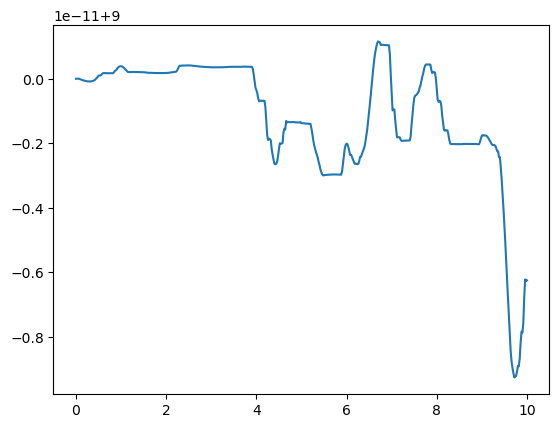

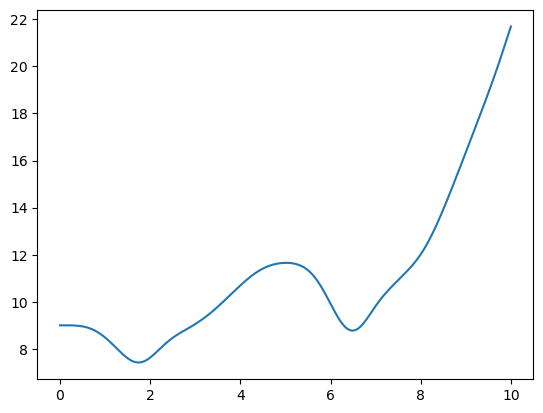

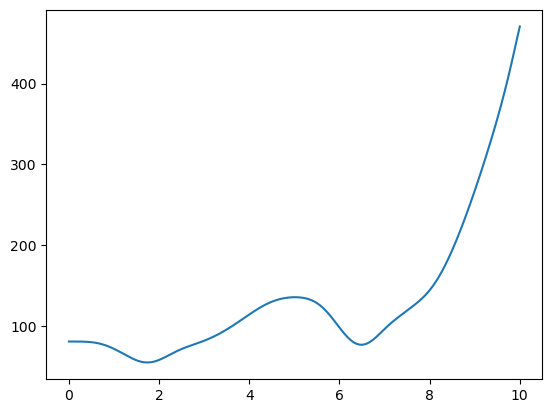

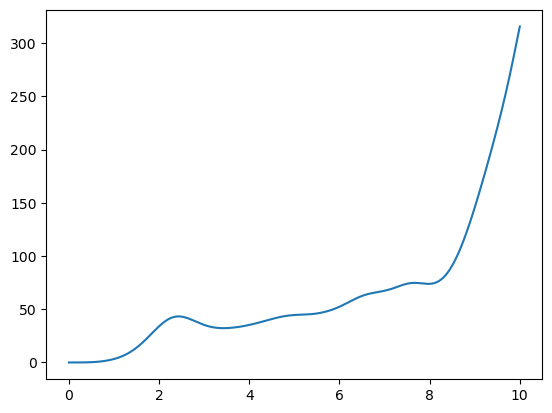

In [144]:
"""
Check purity
"""
# this was purity of 1body rho
# rhosq = np.einsum("ijt,jkt->ikt",rho_soln,rho_soln)
# plt.plot(t_list,np.trace(rhosq, axis1=0,axis2=1))
# plt.show()
plt.plot(soln.t,np.trace(rho2_soln,axis1=0,axis2=1))
plt.show()

plt.plot(soln.t,np.linalg.norm(rho2_soln,axis=(0,1)))
plt.show()

# purity of twobody rho
plt.plot(soln.t,np.trace(   np.einsum('ijt,jkt->ikt',rho2_soln,rho2_soln)    ,axis1=0,axis2=1))
# plt.ylim(0,10)
plt.show()

# purity of correlation part only
# plt.plot(t_list,np.trace(rho2_soln-rho_kron,axis1=0,axis2=1))
plt.plot(soln.t,np.trace(    np.einsum('ijt,jkt->ikt',c2_soln,c2_soln)    ,axis1=0,axis2=1))
# plt.ylim(-1,10)
plt.show()

In [135]:
"""
These dont have much physical meaning, just checking components of 1body rho
"""

# plt.plot(soln.t,rho_soln[0,0].real,label='real')
# plt.plot(soln.t,rho_soln[0,0].imag,label='imag')
# plt.legend()
# plt.show()

# plt.plot(soln.t,rho_soln[1,1].real,label='real')
# plt.plot(soln.t,rho_soln[1,1].imag,label='imag')
# plt.legend()
# plt.show()

# plt.plot(soln.t,rho_soln[0,0].real+rho_soln[1,1].real,label='L + R')
# plt.legend()
# plt.show()

'\nThese dont have much physical meaning, just checking components of 1body rho\n'

mu= 0.5
V: 2.250,1.850,1.553
T: 1.500,1.900,2.197
E: 3.750,3.750,3.750


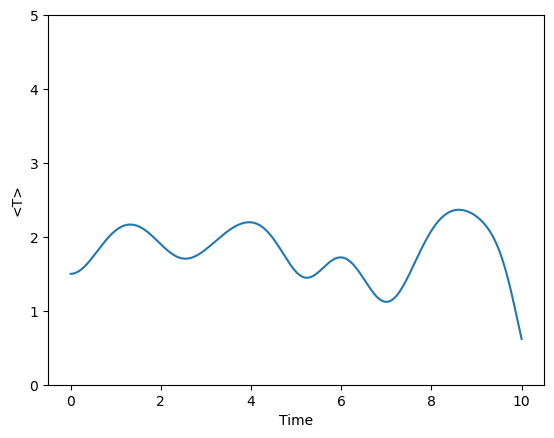

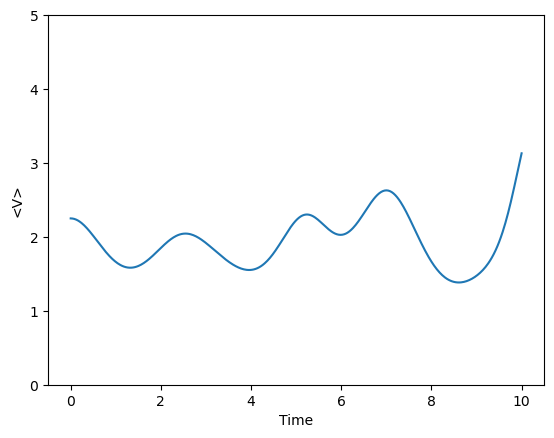

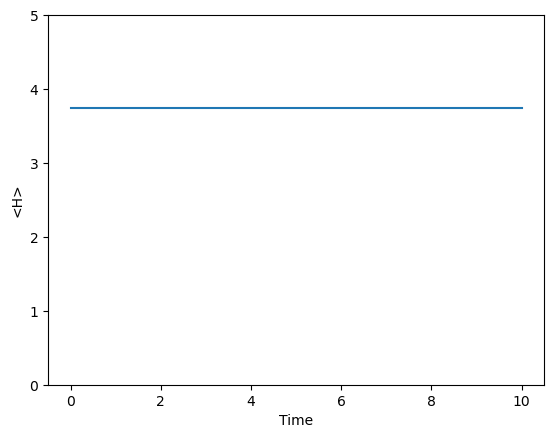

In [129]:
"""
Check energy conservation
"""
a=1
print('mu=',mu)

h0 = a/2*np.array([[1,-1],
                   [-1,1]],dtype=complex)
v = np.array([[mu,0,0,0],
              [0,0,0,0],
              [0,0,0,0],
              [0,0,0,mu]],dtype=complex)
H = np.array([[a+mu,-a/2,-a/2,0],
              [-a/2,a,0,-a/2],
              [-a/2,0,a,-a/2],
              [0,-a/2,-a/2,a+mu]], dtype=complex)

# kinetic first (1body)
T = np.trace( np.einsum("ijt,jk->ikt",rho_soln,h0), axis1=0, axis2=1)
                # # now total
                # E = np.trace( np.einsum("ijt,jk->ikt",rho2_soln,H), axis1=0, axis2=1)
                # print(f'E: {E[0].real:.3f},{E[100].real:.3f},{E[200].real:.3f}')
# now potential (2body)
V = 0.5*np.trace( np.einsum("ijt,jk->ikt",rho2_soln,v), axis1=0, axis2=1)
print(f'V: {V[0].real:.3f},{V[100].real:.3f},{V[200].real:.3f}')

E = T + V
print(f'T: {T[0].real:.3f},{T[100].real:.3f},{T[200].real:.3f}')
print(f'E: {E[0].real:.3f},{E[100].real:.3f},{E[200].real:.3f}')


plt.plot(soln.t,T)
plt.ylabel('<T>')
plt.xlabel('Time')
plt.ylim(0,5)
plt.show()

plt.plot(soln.t,V)
plt.ylabel('<V>')
plt.xlabel('Time')
plt.ylim(0,5)
plt.show()

plt.plot(soln.t,E)
plt.ylabel('<H>')
plt.xlabel('Time')
plt.ylim(0,5)
plt.show()

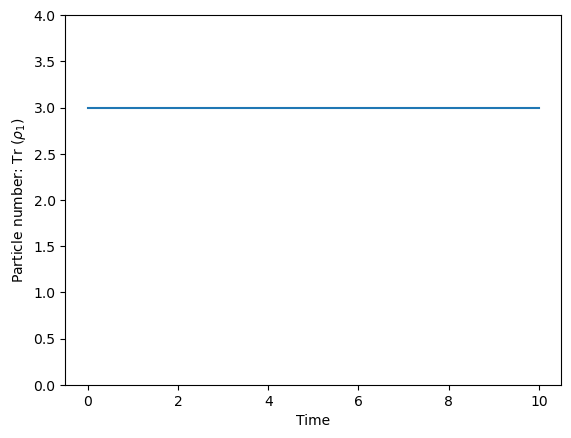

In [134]:
"""
particle number should be conserved
"""

plt.plot(soln.t,np.trace(rho_soln,axis1=0,axis2=1))
plt.ylim(0,4)
plt.ylabel(r'Particle number: Tr $(\rho_1)$')
plt.xlabel('Time')
plt.show()


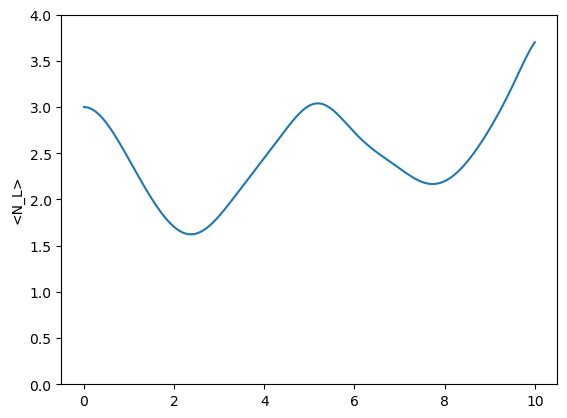

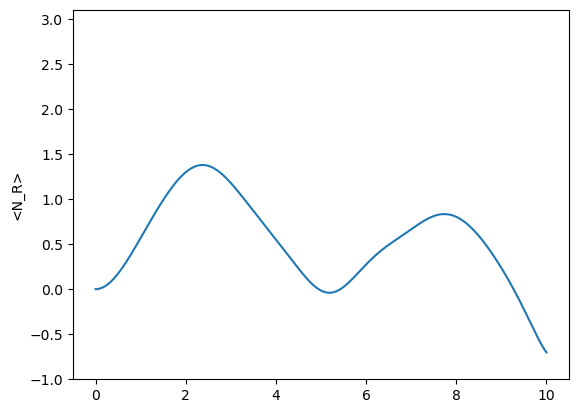

In [85]:
"""
Check number of particles in the left
"""

def NL(rho):
    L = np.array([[1,0],[0,0]],dtype=complex)
    return np.trace(np.einsum("ijt,jk->ikt",rho,L), axis1=0,axis2=1)

def NR(rho):
    R = np.array([[0,0],[0,1]],dtype=complex)
    return np.trace(np.einsum("ijt,jk->ikt",rho,R), axis1=0,axis2=1)

plt.plot(soln.t,NL(rho_soln))
plt.ylim(0,4)
plt.ylabel('<N_L>')
plt.show()

plt.plot(soln.t,NR(rho_soln))
plt.ylabel('<N_R>')
plt.ylim(-1,3.1)
plt.show()

### Exact soln 3 particles in toy model ###

H (8, 8)
501
(2, 2, 2, 2, 2, 2, 501)
rho12 (2, 2, 2, 2, 501)
(2, 2, 501)


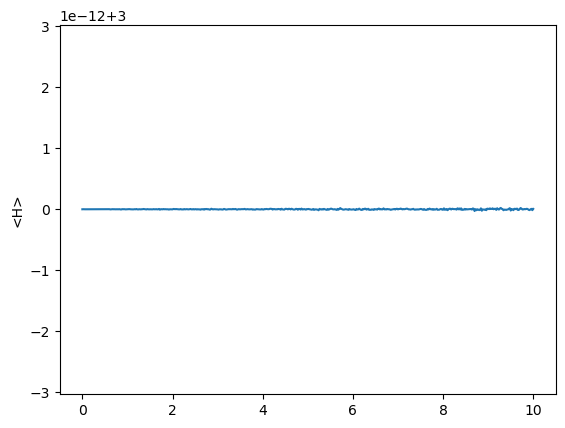

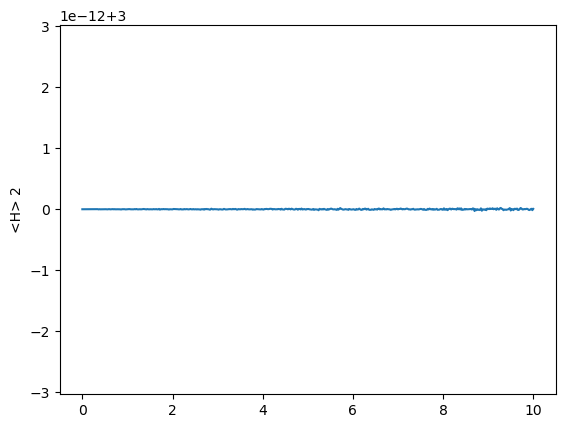

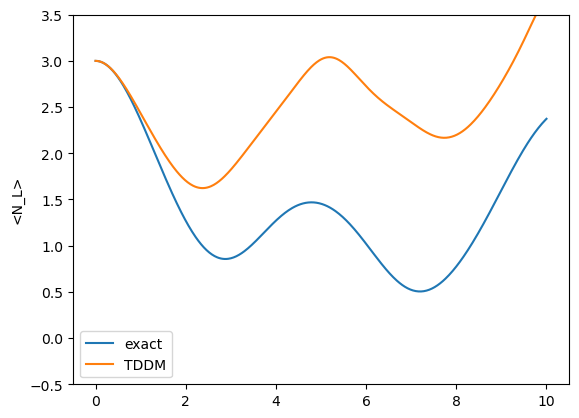

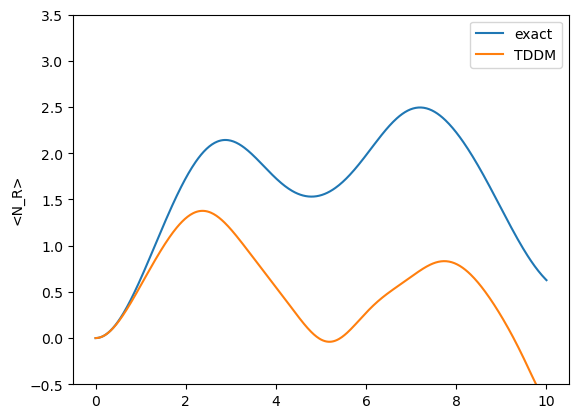

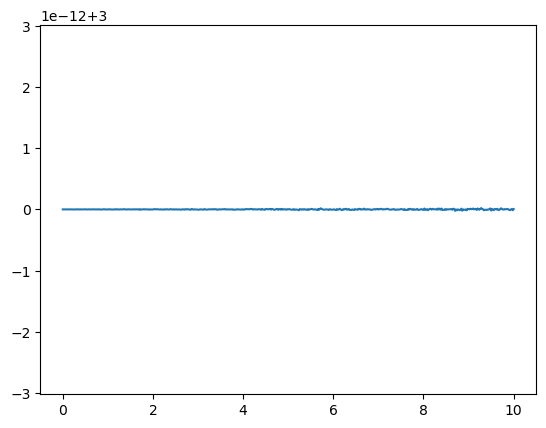

In [146]:
# set up the system and hamiltonian 
mu = 0.5

h0 = a/2*np.array([[1,-1],
                   [-1,1]],dtype=complex)
v = np.array([[mu,0,0,0],
              [0,0,0,0],
              [0,0,0,0],
              [0,0,0,mu]],dtype=complex)
I2 = np.eye(2,dtype=complex)
P23 = np.array([[1, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 1, 0, 0, 0, 0, 0],
                [0, 1, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 1, 0, 0, 0, 0],
                [0, 0, 0, 0, 1, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 1, 0],
                [0, 0, 0, 0, 0, 1, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 1]], dtype=complex)
T = np.kron(np.kron(h0,I2),I2) + np.kron(np.kron(I2,h0),I2) + np.kron(np.kron(I2,I2),h0)
V = np.kron(v,I2) + P23@np.kron(v,I2)@P23.T.conj() + np.kron(I2,v)
H = T+V
print('H',H.shape)

# set up the state evolution
def rhoout(t_list,psiin):
    rhoout=[]
    for t in t_list:
        psiout = expm(-1j*H*t)@psiin
        rho = np.outer(psiout.T.conj(),psiout)
        rho = rho.reshape(2,2,2,2,2,2)
        rhoout.append(rho)
    rhoout = np.array(rhoout,dtype=complex)
    rhoout = np.moveaxis(rhoout, 0, -1)
    return rhoout

# calculate the state evolution
L1 = np.array([1,0],dtype=complex)
psiin = np.kron(np.kron(L1,L1),L1)
t_list = np.linspace(0.0,10.0,501)
print(len(t_list))
rhoout_exact = rhoout(t_list,psiin)
print(rhoout_exact.shape)

# make reduced density matrices
rho12_exact = (3*2)*np.trace(rhoout_exact,axis1=2,axis2=5)
print('rho12',rho12_exact.shape)
rho1_exact = (3*2/2)*np.trace(   np.trace(rhoout_exact,axis1=2,axis2=5)   ,axis1=1,axis2=3)
print(rho1_exact.shape)


# Look at energy conservation
# first using full rho and full H
rhoout_8x8 = rhoout_exact.reshape(8,8,len(t_list))
exE = np.trace( np.einsum('ijt,jk->ikt',rhoout_8x8,H) , axis1=0, axis2=1)
plt.plot(t_list,exE)
plt.ylabel('<H>')
plt.show()

# now using reduced densities and 1body, 2body components of H
exE2 = np.trace( np.einsum('ijt,jk->ikt',rho1_exact,h0) , axis1=0, axis2=1) + 0.5*np.trace( np.einsum('ijt,jk->ikt',rho12_exact.reshape(4,4,len(t_list)),v) , axis1=0, axis2=1)
plt.plot(t_list,exE2)
plt.ylabel('<H> 2')
plt.show()
# CLEARLY NEED THE FACTOR OF 0.5 INFRONT OF 2BODY V TERM SO THAT GET THE SAME E AND ALSO SO THAT E IS CONSERVED 



# Now look at number of particles in each well
plt.plot(t_list,NL(rho1_exact),label='exact')
plt.plot(soln.t,NL(rho_soln),label='TDDM')
plt.ylabel('<N_L>')
plt.ylim(-0.5,3.5)
plt.legend()
plt.show()

plt.plot(t_list,NR(rho1_exact),label='exact')
plt.plot(soln.t,NR(rho_soln),label='TDDM')
plt.ylabel('<N_R>')
plt.ylim(-0.5,3.5)
plt.legend()
plt.show()


# testing some properties of the 2body density, to inform code above. 
# first, the trace stays at 6:
    # plt.plot(t_list,np.trace(rho12_exact.reshape(4,4,len(t_list)),axis1=0,axis2=1))
    # plt.show()
# the norm starts at 6 but is not conserved, thats fine 
    # plt.plot(t_list,np.linalg.norm(rho12_exact.reshape(4,4,len(t_list)),axis=(0,1)))
    # plt.show()

# the 1body density trace stays at 3 as expected (particle number) 
    # plt.plot(t_list,np.trace(rho1_exact,axis1=0,axis2=1))
    # plt.show()